# Reproducing The Nishimori Point, $p_c$

A self-contained Jupyter notebook the 2D RBIM transfer-matrix project. 
Run cells top to bottom.

**Structure**
1. The Engine (transfer matrix, partition function, domain-wall energy cost)
2. Validation Tests (A: Onsager and B: Nishimori exact energy)
3. Main Result (pair-wise intersections, crossing point = Nishimori point!)

In [20]:
import numpy as np
from scipy import integrate
from scipy.ndimage import gaussian_filter
from scipy.stats import norm
from scipy.optimize import least_squares
import itertools, json, time
import matplotlib.pyplot as plt
%matplotlib inline

## 1. The engine

Run all cells to begin.
This sets up the foundations for finding the transfer matrices and partition functions.

Spins $\sigma_{mn}=\pm1$ on sites $(m,n)$: $n=0,\dots,N-1$ (longitudinal direction),
$n=0,\dots,L-1$ (transverse direction, w/ periodic/anti-periodic boundary conditions) which form basis states for the transfer matrix.

In [2]:
def nishimori_K(p):

    '''Coupling on the Nishimori line: tanh K = 1 - 2p, which is equivalent to K = ln[(1-p)/p] / 2.'''

    return 0.5 * np.log((1.0 - p) / p)

def sigma_products(L):

    '''S[s, i] = s_i * s_{i+1 mod L}, shape (2**L, L).'''
    
    states = np.arange(2 ** L)
    sig = 1.0 - 2.0 * ((states[:, None] >> np.arange(L)[None, :]) & 1)
    
    return sig * np.roll(sig, -1, axis=1)

In [3]:
def sample_iid(L, N, p, rng, fixed_concentration=True):
    
    '''iid bit-flip error model: tau_v, tau_h = +1 with probability 1-p, -1 with probability p. If fixed_concentration is True, then exactly p*(nv+nh) bonds are flipped.'''

    nv, nh = N * L, (N - 1) * L
    tau = np.ones(nv + nh)
    
    if fixed_concentration:
        idx = rng.choice(nv + nh, size=int(round(p * (nv + nh))), replace=False)
        tau[idx] = -1.0
    else:
        tau[rng.random(nv + nh) < p] = -1.0

    return tau[:nv].reshape(N, L), tau[nv:].reshape(N - 1, L)

In [15]:
def log_Z_strip(tau_v, tau_h, K, antiperiodic=False, S=None,
                Kh=None):
    '''Exact log Z of an L x N strip via the transfer matrix.'''

    N, L = tau_v.shape
    if S is None:
        S = sigma_products(L)
    if Kh is None:
        Kh = K

    tv = tau_v.copy()
    if antiperiodic:
        tv[:, L - 1] *= -1.0   # flipping the seam bonds <-> antiperiodic boundary conditions / twist in topology

    v = np.ones(2 ** L)
    logZ = 0.0
    for n in range(N):
        expo = K * (S @ tv[n])
        v *= np.exp(expo)

        if n < N - 1:
            a = np.exp(Kh * tau_h[n])
            b = 1.0 / a
            for i in range(L):
                w = v.reshape(2 ** (L - 1 - i), 2, 2 ** i)
                w0 = w[:, 0, :].copy()
                w1 = w[:, 1, :].copy()
                w[:, 0, :] = a[i] * w0 + b[i] * w1
                w[:, 1, :] = b[i] * w0 + a[i] * w1

        c = v.max() # re-scale to avoid overflow
        v /= c
        logZ += np.log(c)
        
    return logZ + np.log(v.sum())

def free_energy_density(tau_v, tau_h, K, antiperiodic=False, S=None, **kw):

    '''f = log Z / (L*N), free-energy per site.'''

    N, L = tau_v.shape

    return log_Z_strip(tau_v, tau_h, K, antiperiodic, S, **kw) / (L * N)

def domain_wall_free_energy(L, N, p, rng, n_samples, sampler=sample_iid,
                            K=None, sampler_kw=None, **tm_kw):
    
    '''d_L = L^2 (f^(p) - f^(a)), averaged over disorder. Periodic and
    antiperiodic free energies use the SAME disorder sample.'''

    if K is None:
        K = nishimori_K(p)

    sampler_kw = sampler_kw or {}
    S = sigma_products(L)
    vals = np.empty(n_samples)

    for m in range(n_samples):
        tv, th = sampler(L, N, p, rng, **sampler_kw)
        fp = free_energy_density(tv, th, K, False, S, **tm_kw)
        fa = free_energy_density(tv, th, K, True, S, **tm_kw)
        vals[m] = L * L * (fp - fa)

    return vals.mean(), vals.std(ddof=1) / np.sqrt(n_samples), vals

## 2. Validation Tests

Test A checks the pure Ising model against Onsager's exact solution; Test B checks Nishimori's exact
internal energy identity on the Nishimori line.

Run the first cell (functions) then change the parameters in the second cell as desired and then run it to generate the test results. The benchmark numbers are printed out as well.

In [ ]:
KC = 0.5 * np.log(1 + np.sqrt(2))   # pure-Ising critical point

def onsager_free_energy(K):

    '''-beta*f for the 2D Ising model (J=1), via the single-integral form
       from the dissertation.
    '''

    kappa = 2 * np.sinh(2*K) / np.cosh(2*K)**2

    def integrand(phi):
        arg = 1 - kappa**2 * np.sin(phi)**2
        arg = max(arg, 0.0)         
        return np.log(0.5 * (1 + np.sqrt(arg)))

    val, _ = integrate.quad(integrand, 0, np.pi, limit=200, epsabs=1e-10)
    return np.log(2 * np.cosh(2*K)) + val / (2 * np.pi)

def test_A(Ls, N):

    print("=== Test A: pure Ising at K_c vs Onsager, and c = 1/2 ===")

    fs = {}
    for L in Ls:
        tv, th = np.ones((N, L)), np.ones((N-1, L))
        fs[L] = free_energy_density(tv, th, KC)
        print(f"  L={L:2d}  f_L = {fs[L]:.7f}")
    Lf = np.array(Ls[-3:], dtype=float)
    y = np.array([fs[int(L)] for L in Lf])
    A = np.vstack([np.ones_like(Lf), np.pi/(6*Lf**2)]).T
    finf, c = np.linalg.lstsq(A, y, rcond=None)[0]

    print(f"  fit  f_inf = {finf:.7f}   c = {c:.4f}")
    print(f"  exact      = {onsager_free_energy(KC):.7f}       c = 0.5")

def test_B(p, L, N, M, dK, seed):

    print("=== Test B: Nishimori exact internal energy ===")
    
    K, rng, S = nishimori_K(p), np.random.default_rng(seed), sigma_products(L)
    Nb = N*L + (N-1)*L
    E = []
    for _ in range(M):
        tv, th = sample_iid(L, N, p, rng, fixed_concentration=False)
        lp = log_Z_strip(tv, th, K+dK, False, S)
        lm = log_Z_strip(tv, th, K-dK, False, S)
        E.append(-(lp-lm)/(2*dK)/Nb)
    E = np.array(E)

    print(f"  K_N({p}) = {K:.6f},  tanh K_N = {np.tanh(K):.6f},  1-2p = {1-2*p:.6f}")
    print(f"  measured [<H>]/N_b = {E.mean():.6f} +- {E.std(ddof=1)/np.sqrt(M):.6f}")
    print(f"  exact              = {-np.tanh(K):.6f}")

In [ ]:
Ls = (6,8,10) # circumference lengths to scan over
N = 1000 # longitudinal length
test_A(Ls, N)
print()

p = 0.1 # error-rate
L = 8 # circumference length
N = N # longitudinal length
M = 20 # no. of repetitions
dK = 1e-3 # step size for central difference method to find derivative
seed = 1 
test_B(p, L, N, M, dK, seed)
print()

=== Test A: pure Ising at K_c vs Onsager, and c = 1/2 ===
  L= 6  f_L = 0.9369188
  L= 8  f_L = 0.9336457
  L=10  f_L = 0.9321490
  fit  f_inf = 0.9294590   c = 0.5127
  exact      = 0.9296954       c = 0.5

=== Test B: Nishimori exact internal energy ===
  K_N(0.1) = 1.098612,  tanh K_N = 0.800000,  1-2p = 0.800000
  measured [<H>]/N_b = -0.799995 +- 0.000963
  exact              = -0.800000



## 3. Main Results

Using finite-size scaling to find the critical point / error threshold. Final output is the main graph.

First cell is the parameters to be adjusted as desired. After than, one can rest the rest of the code to generate the final output.

In [16]:
L_list   = [6, 8, 10] # circumference lengths to scan over
p_list   = [0.105, 0.107, 0.109, 0.111, 0.113] # centred on p_c = 0.1094(2)
N        = 1000 # longitudinal length
M        = 20 # no. of repetitions
seed     = 0 # fixed seed to generate disorder sample
noise    = "iid"     # error model type
out_file = "scan.json"  # outputs raw data; set to None to skip writing a file

In [17]:
sampler, skw, tmkw = sample_iid, {}, {}

In [18]:
results = {"meta": {"L": L_list, "p": p_list, "N": N, "M": M, "seed": seed,
                    "noise": noise},
           "data": {}}
t0 = time.time()
for L in L_list:
    for p in p_list:
        rng = np.random.default_rng(seed + 1000*L + int(p * 1e5))
        m, e, vals = domain_wall_free_energy(
            L, N, p, rng, M, sampler=sampler, sampler_kw=skw, **tmkw)
        results["data"][f"L{L}_p{p:.5f}"] = vals.tolist()
        print(f"L={L:2d} p={p:.4f}  d_L = {m:.4f} +- {e:.4f}"
              f"   [{time.time()-t0:.0f}s]", flush=True)

if out_file:
    json.dump(results, open(out_file, "w"))
    print("written to", out_file)

L= 6 p=0.1050  d_L = 2.4392 +- 0.0273   [2s]
L= 6 p=0.1070  d_L = 2.2404 +- 0.0251   [5s]
L= 6 p=0.1090  d_L = 2.1737 +- 0.0288   [7s]
L= 6 p=0.1110  d_L = 2.0484 +- 0.0281   [10s]
L= 6 p=0.1130  d_L = 1.9781 +- 0.0213   [12s]
L= 8 p=0.1050  d_L = 2.4962 +- 0.0297   [16s]
L= 8 p=0.1070  d_L = 2.3181 +- 0.0346   [19s]
L= 8 p=0.1090  d_L = 2.1653 +- 0.0250   [23s]
L= 8 p=0.1110  d_L = 1.9910 +- 0.0276   [27s]
L= 8 p=0.1130  d_L = 1.9061 +- 0.0247   [30s]
L=10 p=0.1050  d_L = 2.5321 +- 0.0417   [37s]
L=10 p=0.1070  d_L = 2.3868 +- 0.0299   [43s]
L=10 p=0.1090  d_L = 2.1162 +- 0.0494   [50s]
L=10 p=0.1110  d_L = 1.9646 +- 0.0477   [56s]
L=10 p=0.1130  d_L = 1.8521 +- 0.0303   [63s]
written to scan.json


In [ ]:
# results = json.load(open("scan.json"))   # uncomment to reload from disc instead

def _as_data_dict(results):

    d = {}
    for k, v in results["data"].items():
        Lstr, pstr = k.split("_")
        d.setdefault(int(Lstr[1:]), {})[float(pstr[1:])] = np.asarray(v)
        
    return d

data = _as_data_dict(results)

In [22]:
def crossing(d, L1, L2, resample=False, rng=None):

    '''Root of d_{L1} - d_{L2} by local quadratic interpolation.'''

    ps = np.array(sorted(set(d[L1]) & set(d[L2])))
    def mean(L, p):
        v = d[L][p]
        return rng.choice(v, size=len(v)).mean() if resample else v.mean()
    g = np.array([mean(L1, p) - mean(L2, p) for p in ps])
    sgn = np.where(np.sign(g[:-1]) * np.sign(g[1:]) < 0)[0]
    if len(sgn) == 0:
        return np.nan
    k = sgn[0]
    lo, hi = max(k-1, 0), min(k+3, len(ps))
    c = np.polyfit(ps[lo:hi], g[lo:hi], min(2, hi-lo-1))
    roots = np.roots(c)
    roots = roots[np.isreal(roots)].real
    roots = roots[(roots > ps[0]) & (roots < ps[-1])]
    return roots[np.argmin(abs(roots - ps[k]))] if len(roots) else np.nan

def crossings(d, n_boot=200, seed=0):

    rng = np.random.default_rng(seed)
    print("--- finite-size crossings ---")
    res = {}

    for L1, L2 in itertools.combinations(sorted(d), 2):
        pc = crossing(d, L1, L2)
        bs = np.array([crossing(d, L1, L2, True, rng) for _ in range(n_boot)])
        bs = bs[np.isfinite(bs)]
        err = bs.std(ddof=1) if len(bs) > 5 else np.nan
        res[(L1, L2)] = (pc, err)
        print(f"  p_c({L1:2d},{L2:2d}) = {pc:.5f} +- {err:.5f}")

    return res

def collapse(d, pc0=0.109, nu0=1.33, deg=3): # parameters taken from Honceker et al. (2006) as the initial guess

    pts = [(L, p, v.mean(), v.std(ddof=1)/np.sqrt(len(v)))
           for L in d for p, v in d[L].items()]
    L_, p_, y_, s_ = map(np.asarray, zip(*pts))

    def resid(th):
        pc, nu = th[0], th[1]
        x = (p_ - pc) * L_**(1.0/nu)

        return (np.polyval(th[2:], x) - y_) / s_
    
    th0 = np.concatenate([[pc0, nu0], np.polyfit((p_-pc0)*L_**(1/nu0), y_, deg)])
    fit = least_squares(resid, th0)
    dof = max(len(y_) - len(th0), 1)
    chi2 = 2 * fit.cost / dof
    J = fit.jac
    cov = np.linalg.pinv(J.T @ J) * max(chi2, 1.0)

    print("--- extrapolation ---")
    print(f"  p_c = {fit.x[0]:.5f} +- {np.sqrt(cov[0,0]):.5f}")
    print(f"  nu  = {fit.x[1]:.4f} +- {np.sqrt(cov[1,1]):.4f}")
    print("  HPP 2006: p_c = 0.1094(2),  nu = 1.33(3)")

    return fit.x, cov

In [ ]:
xres = crossings(data)

def extrapolated_pc(xres):

    """Weighted linear extrapolation of pairwise crossings vs 1/Lbar^2,
    Lbar = (L1+L2)/2 --- the form used by Picco, Honecker & Pujol (2006),
    motivated by the known L^-2 finite-size correction to p_c."""

    pairs = {k: v for k, v in xres.items() if np.isfinite(v[0]) and np.isfinite(v[1]) and v[1] > 0}
    Lbar = np.array([(k[0]+k[1])/2 for k in pairs])
    y    = np.array([v[0] for v in pairs.values()])
    err  = np.array([v[1] for v in pairs.values()])
    x, w = 1.0/Lbar**2, 1.0/err**2
    X, W = np.vstack([np.ones_like(x), x]).T, np.diag(w)
    beta = np.linalg.solve(X.T@W@X, X.T@W@y)
    cov  = np.linalg.inv(X.T@W@X)

    return beta[0], np.sqrt(cov[0,0])

pc_extrap, pc_extrap_err = extrapolated_pc(xres)

--- finite-size crossings ---
  p_c( 6, 8) = 0.10941 +- 0.00144
  p_c( 6,10) = 0.10916 +- 0.00107
  p_c( 8,10) = 0.10867 +- 0.00185
p_c (bias-corrected) = 0.10780 +- 0.00462       (Honecker et al. 2006: 0.1094 +- 0.0002)


p_c (bias-corrected) = 0.10780 +- 0.00462       (Honecker et al. 2006: 0.1094 +- 0.0002)
saved d_L_crossing.pdf


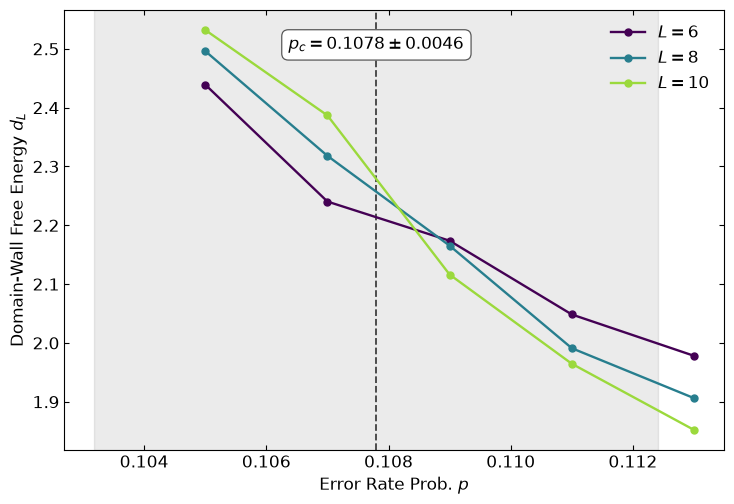

In [ ]:
plt.rcParams.update({
    "font.size": 12, "font.family": "sans-serif",
    "axes.spines.top": True, "axes.spines.right": True,
    "xtick.direction": "in", "ytick.direction": "in",
    "xtick.top": True, "ytick.right": True,
    "pdf.fonttype": 42,  
})

fig, ax = plt.subplots(figsize=(7.5, 5.2))
colors = plt.cm.viridis(np.linspace(0, 0.85, len(sorted(data))))

for color, L in zip(colors, sorted(data)):

    ps = np.array(sorted(data[L]))
    ys = np.array([data[L][p].mean() for p in ps])
    errs = np.array([data[L][p].std(ddof=1) / np.sqrt(len(data[L][p])) for p in ps])
    ax.errorbar(ps, ys, marker="o", ms=5, lw=1.7, color=color,
                label=f"$L={L}$", capsize=2, zorder=3)

ax.axvline(pc_extrap, color="0.25", ls="--", lw=1.3, zorder=1)
ax.axvspan(pc_extrap - pc_extrap_err, pc_extrap+ pc_extrap_err, color="0.4", alpha=0.13, zorder=0) # uncertainty bound
ylo, yhi = ax.get_ylim()
ax.annotate(rf"$p_c = {pc_extrap:.4f} \pm {pc_extrap_err:.4f}$",
            xy=(pc_extrap, yhi - 0.06*(yhi - ylo)), ha="center", va="top", fontsize=12,
            bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="0.35", lw=0.9))

ax.set_xlabel(r"Error Rate Prob. $p$")
ax.set_ylabel(r"Domain-Wall Free Energy $d_L$")
#ax.set_title("Locating the Nishimori point from the $d_L(p)$ crossing")
ax.legend(frameon=False, loc="upper right")
fig.tight_layout()
fig.savefig("d_L_crossing.pdf", bbox_inches="tight")
print(f"p_c (bias-corrected) = {pc_extrap:.5f} +- {pc_extrap_err:.5f}       (Honecker et al. 2006: 0.1094 +- 0.0002)")
print("saved d_L_crossing.pdf")